Jonas Inocencio s3787701

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

IMG_DIR = 'images'

# Folder for clean, high-resolution figure exports (used for the report)
FIG_DIR = 'report_figures'
os.makedirs(FIG_DIR, exist_ok=True)

Using device: cuda


## 1. Data Loading

In [2]:
from typing import cast # To remove Pycharm errors on Windows

main = cast(pd.DataFrame, pd.read_csv('data_labels_mainData.csv'))
extra = cast(pd.DataFrame, pd.read_csv('data_labels_extraData.csv'))

print(main.shape, extra.shape)
main.head()

(9896, 6) (10384, 4)


,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [3]:
# Task 1 - isCancerous in both files
df_cancer = pd.concat([main[['patientID','ImageName','isCancerous']],
                       extra[['patientID','ImageName','isCancerous']]],
                      ignore_index=True)

# Task 2 - cellType only in main file
df_type = main[['patientID','ImageName','cellType']].copy()

In [4]:
# Load images to array - regularise RGB values from 0-255 to 0-1
def load_images(df, img_dir=IMG_DIR):
    X = np.zeros((len(df), 27, 27, 3), dtype=np.float32)
    for i, name in enumerate(df['ImageName'].values):
        img = Image.open(os.path.join(img_dir, name)).convert('RGB')
        X[i] = np.asarray(img, dtype=np.float32) / 255.0
    return X

**REPORT**
- Computers recognise images as a grid of pixels with RGB values from 0-255. For example, a purple pixel would be [138, 80, 200].
- To help the models train more stably, RGB values are normalised to be values from 0-1.

## 2. Data Splitting

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

# 60/20/20 split stratified by a target column (cellType or isCancer) to ensure no unlucky splits
def split_by_patient(df, target_col):
    # set aside 20% of patients as the test set (1/5 folds)
    outer_kfold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    development_index, test_index = next(
        outer_kfold.split(df, df[target_col], df['patientID']))
    development_data = df.iloc[development_index]
    test_data        = df.iloc[test_index]

    # set aside another 20% of patients as the validation set
    inner_kfold = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
    train_index, validation_index = next(
        inner_kfold.split(development_data, development_data[target_col],
                          development_data['patientID']))
    train_data      = development_data.iloc[train_index]
    validation_data = development_data.iloc[validation_index]

    return (train_data.reset_index(drop=True),
            validation_data.reset_index(drop=True),
            test_data.reset_index(drop=True))

# train_data_c = CANCER, train_data_t = cellTYPE  (calls unchanged)
train_data_c, val_data_c, test_data_c = split_by_patient(df_cancer, 'isCancerous')
train_data_t, val_data_t, test_data_t = split_by_patient(df_type, 'cellType')

In [6]:
print(f"Cancer   -> train:{train_data_c.shape[0]} val:{val_data_c.shape[0]} test:{test_data_c.shape[0]}")
print(f"CellType -> train:{train_data_t.shape[0]} val:{val_data_t.shape[0]} test:{test_data_t.shape[0]}\n")

# Ensure no patient appears in more than one split
print(f"isCancerous train/test data is disjoint: {set(train_data_c.patientID).isdisjoint(test_data_c.patientID)}")
print(f"isCancerous test/val data is disjoint: {set(test_data_c.patientID).isdisjoint(val_data_c.patientID)}")
print(f"isCancerous val/train data is disjoint: {set(val_data_c.patientID).isdisjoint(train_data_c.patientID)}")
print()
print(f"cellType train/test data is disjoint: {set(train_data_t.patientID).isdisjoint(test_data_t.patientID)}")
print(f"cellType test/val data is disjoint: {set(test_data_t.patientID).isdisjoint(val_data_t.patientID)}")
print(f"cellType val/train data is disjoint: {set(val_data_t.patientID).isdisjoint(train_data_t.patientID)}\n")

# Cell type / cancer classification distribution
for nm, d in [('train',train_data_t),('val',val_data_t),('test',test_data_t)]:
    print(nm, d['cellType'].value_counts(normalize=True).round(2).to_dict())
print()
for nm, d in [('train',train_data_c),('val',val_data_c),('test',test_data_c)]:
    print(nm, d['isCancerous'].value_counts(normalize=True).round(2).to_dict())

Cancer   -> train:12471 val:3870 test:3939
CellType -> train:5829 val:2059 test:2008

isCancerous train/test data is disjoint: True
isCancerous test/val data is disjoint: True
isCancerous val/train data is disjoint: True

cellType train/test data is disjoint: True
cellType test/val data is disjoint: True
cellType val/train data is disjoint: True

train {2: 0.41, 1: 0.25, 0: 0.19, 3: 0.14}
val {2: 0.39, 1: 0.29, 0: 0.18, 3: 0.13}
test {2: 0.43, 1: 0.24, 0: 0.19, 3: 0.14}

train {0: 0.65, 1: 0.35}
val {0: 0.66, 1: 0.34}
test {0: 0.66, 1: 0.34}


**Notes**
- Cells from one patient are correlated. Splitting randomly would have one patient be in multiple sets
- In order to ensure that the models are tested on data they haven't seen, splits are done by patient, not by random row
- Patients are only in one set, stratified by class, so each split is representative and testing is done on unseen patients
- Cell type classes and cancer classes are distributed evenly. scores will be more fair than having a lucky draw

In [7]:
# X is an array of [R, G, B] pixel grids, y is the cellType classification
train_X = load_images(train_data_t)
train_y = train_data_t['cellType'].to_numpy()

val_X   = load_images(val_data_t)
val_y   = val_data_t['cellType'].to_numpy()

test_X  = load_images(test_data_t)
test_y  = test_data_t['cellType'].to_numpy()

## 3. EDA

- Eda is only performed on training data to ensure no data leakage

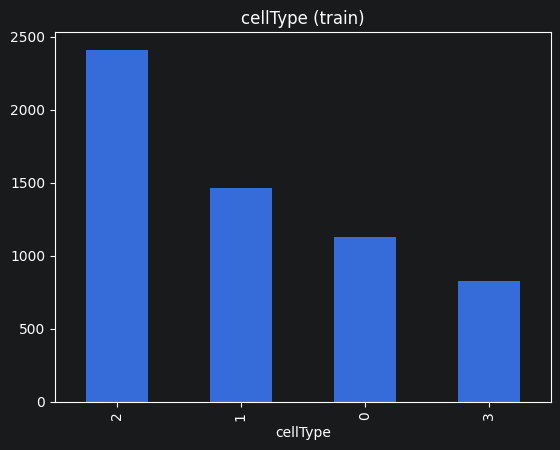

In [8]:
# Class Distribution
train_data_t['cellType'].value_counts().plot(kind='bar')
plt.title('cellType (train)')
plt.savefig(f'{FIG_DIR}/fig01_celltype_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Notes**
- Cell types are imbalanced, justifying macro F1 for evaluation (weight all classes equally so majority class doesn't dominate results)
- the unspecified class ('others') is still quite large. If it isn't well-defined, with no particular patterns, it could result in model innacuracies

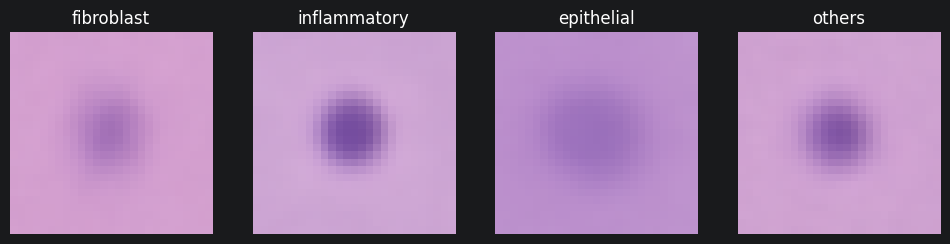

In [9]:
# Visualise the average image per class
fig, ax = plt.subplots(1, 4, figsize=(12,3))
names = ['fibroblast','inflammatory','epithelial','others']

for k in range(4):
    ax[k].imshow(train_X[train_y==k].mean(axis=0))
    ax[k].set_title(names[k])
    ax[k].axis('off')
plt.savefig(f'{FIG_DIR}/fig03_average_image_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

**Notes**
- Average image per class. Visually, we can see that there is a rather clear distinction between each class in terms of width and darkness.

In [10]:
# Relationship between cellType and isCancerous
print(main.groupby('cellTypeName')['isCancerous'].value_counts())

cellTypeName  isCancerous
epithelial    1              4079
fibroblast    0              1888
inflammatory  0              2543
others        0              1386
Name: count, dtype: int64


**Observations**
- Perfect correlation between epithelial cellType and isCancerous
- Every non-epithelial cell type is non-cancerous
- epithelial --> cancerous, anything else --> non-cancerous
- On the main data, cancer detection becomes identifying epithelial cells, but the extra dataset doesn't have the cellType column. Could cause issues

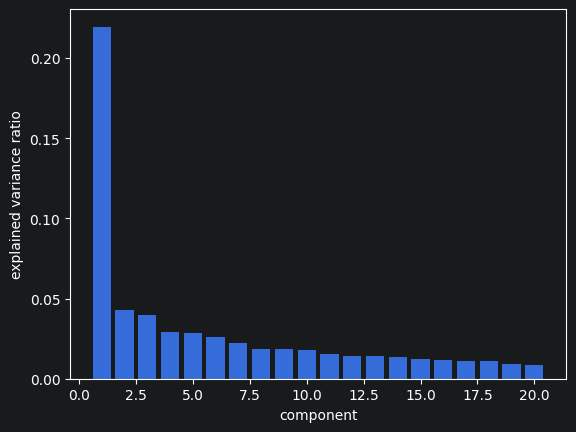

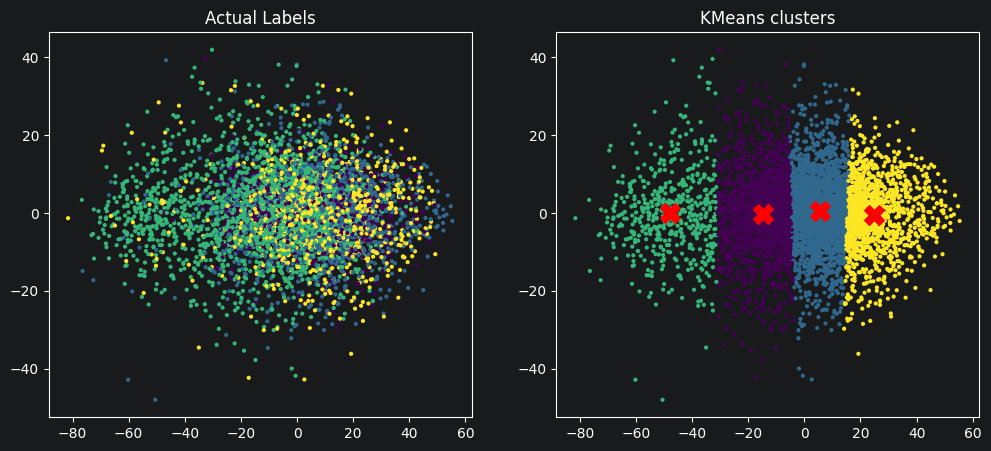

In [11]:
# Dimensionality Reduction and Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Flatten image RGB grids
X_flat = train_X.reshape(train_X.shape[0], -1)
X_flat = StandardScaler().fit_transform(X_flat)

# Dimensionality Reduction
pca = PCA(n_components=20).fit(X_flat)
plt.bar(np.arange(1,21), pca.explained_variance_ratio_)
plt.xlabel('component')
plt.ylabel('explained variance ratio')
plt.savefig(f'{FIG_DIR}/fig04a_pca_explained_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# Project to 2D, colour by true label (Week 10)
pca2 = PCA(n_components=2).fit(X_flat)
proj = pca2.transform(X_flat)

# KMeans, then plot true labels vs clusters side by side (Week 10)
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
kmeans.fit(proj)
y_kmeans = kmeans.predict(proj)
centers  = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(proj[:, 0], proj[:, 1], c=train_y, cmap='viridis', s=4)
axes[0].set_title("Actual Labels")
axes[1].scatter(proj[:, 0], proj[:, 1], c=y_kmeans, cmap='viridis', s=4)
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
axes[1].set_title("KMeans clusters")
plt.savefig(f'{FIG_DIR}/fig04b_pca_projection_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations**
- 2 components do not capture much, as raw pixels are noisy.
- We can see that there is quite a bit of class overlap (though the purple trends higher, and the green shifts lower)
- Little variance and heavy class overlap suggests that models using flattened datasets may struggle. CNN, using spatial relationships, may be better suited

## 4. Pre-Processing

In [12]:
# Scaler. Fit ONLY on training set
from sklearn.preprocessing import StandardScaler

train_X = train_X.reshape(train_X.shape[0], -1)
val_X = val_X.reshape(val_X.shape[0], -1)
test_X = test_X.reshape(test_X.shape[0], -1)

scaler = StandardScaler()
scaler.fit(train_X)

train_X = scaler.transform(train_X)
val_X = scaler.transform(val_X)
test_X = scaler.transform(test_X)

**Notes**
- No need for encoding here. Data is either a pixel grid or an integer encoding of the cell type

## 5. Model Evaluation

In [13]:
# Helper function to get macro F1 scores for train and validation set
from sklearn.metrics import f1_score

def get_f1_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)
    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y,   val_pred,   average='macro')
    return train_f1, val_f1

### 5.1. Basic Models - Logistic Regression, SVM, Random Forest

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
clf_lr = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_lr.fit(train_X, train_y.ravel())
print("LR  :", get_f1_scores(clf_lr, train_X, train_y, val_X, val_y))

# SVM - RBF kernel
clf_svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=SEED)
clf_svm.fit(train_X, train_y.ravel())
print("SVM :", get_f1_scores(clf_svm, train_X, train_y, val_X, val_y))

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
clf_rf.fit(train_X, train_y.ravel())
print("RF  :", get_f1_scores(clf_rf, train_X, train_y, val_X, val_y))

LR  : (0.9520798635794774, 0.4874581566964762)
SVM : (0.9121259736014256, 0.6736658071867931)
RF  : (0.9995608578086126, 0.5920330114790262)


**Notes**
- Each model runs on flattened (27 x 27 x 3) pixel vectors, so the spacial connections are lost for the most part
- Every model overfits as shown by the significant performance discrepancy between train and validation sets
- Their train set is rather large, so this isn't too surprising. Because of the large training data, they memorise the training set, but the limitations of the models result in poor generalisation
- Looking at validation, SVM > RF, LR
- LR: Linear boundary is able to memorise patterns from the training data, but model is too simple to generalise
- SVM: Has the best generalisation of the three, surpassing the 0.6 target. RBF kernel captures non-linearity well, but the high feature count results in long training times
- RF: Has the largest training/validation gap. The deep trees almost entirely memorise the training set, but are unable to generalise well, signifying heavy overfitting. Still performs slightly better than Logistic Regression.

### 5.2. Advanced Model - Convolutional Neural Network

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# LABEL_COL = 'isCancerous'
LABEL_COL = 'cellType'

# dataframe to pytorch link. Stores DataFrame and can fetch items
class CellDataset(Dataset):
    def __init__(self, dataframe, directory, label_col, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.directory = directory
        self.label_col = label_col
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.directory, row['ImageName'])).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label

Using device: cuda


In [16]:
# Define transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
val_transform = train_transform

batch_size = 64

# Create dataloaders
train_loader = DataLoader(
    CellDataset(train_data_t, IMG_DIR, LABEL_COL, train_transform),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    CellDataset(val_data_t, IMG_DIR, LABEL_COL, val_transform),
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    CellDataset(test_data_t,IMG_DIR, LABEL_COL, val_transform),
    batch_size=batch_size,
    shuffle=False
)

**Notes**
- DataLoaders read images through CellDataset and apply ToTensor and Normalise. CNN uses raw 27 x 27 x 3 grid, not flattened arrays that the simpler models used

In [17]:
# VGG-style CNN with an optional BatchNorm toggle (use_bn).
# Implemented as a constructor flag rather than commenting lines in/out, so that
# both the BN and non-BN variants are reproducible in a single "Restart & Run All".
class VGGNet(nn.Module):
    def __init__(self, output_classes, dropout=0.0, use_bn=False):
        super().__init__()

        def conv_block(in_ch, out_ch):
            layers = [nn.Conv2d(in_ch, out_ch, 3, padding=1)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_ch))   # BN before the non-linearity
            layers.append(nn.ReLU(inplace=True))
            return layers

        self.features = nn.Sequential(
            *conv_block(3, 32),
            *conv_block(32, 32),
            nn.MaxPool2d(2),
            *conv_block(32, 64),
            *conv_block(64, 64),
            nn.MaxPool2d(2),
            *conv_block(64, 128),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, output_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


**Notes**
- `VGGNet` takes a `use_bn` flag. With `use_bn=True`, a `BatchNorm2d` layer is inserted after every convolution (before the ReLU) to stabilise and speed up training.
- This is a constructor argument rather than commented-out code, so the BN and non-BN runs both reproduce on "Restart & Run All".


In [18]:
# Takes lists (train loss, val loss, train metric, val metric) and draws two graphs over epochs
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Macro-F1', save_path=None):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train','val'])
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train','val'])
    plt.grid()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
import copy

# PyTorch Training Loop
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    run_loss = 0.0
    ys = []
    ps = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item() * images.size(0)
        ys += labels.cpu().tolist()
        ps += outputs.argmax(1).cpu().tolist()
    return run_loss / len(loader.dataset), f1_score(ys, ps, average='macro')

def evaluate(model, loader, criterion, device):
    model.eval()
    run_loss = 0.0
    ys = []
    ps = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            run_loss += criterion(outputs, labels).item() * images.size(0)

            ys += labels.cpu().tolist()
            ps += outputs.argmax(1).cpu().tolist()
    return run_loss / len(loader.dataset), f1_score(ys, ps, average='macro')

def train_model(model, train_loader, val_loader, epochs=60, lr=1e-3,
                weight_decay=0.0, class_weights=None, save_path=None,
                smooth_window=3, patience=None):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=None if class_weights is None else class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'loss': [], 'val_loss': [], 'f1': [], 'val_f1': []}
    best_smoothed, best_state, stale = -1, None, 0

    for epoch in range(epochs):
        tr_loss, tr_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_f1 = evaluate(model, val_loader, criterion, device)
        history['loss'].append(tr_loss);    history['f1'].append(tr_f1)
        history['val_loss'].append(va_loss); history['val_f1'].append(va_f1)

        # select on a moving average of val-F1, not one noisy epoch
        smoothed = np.mean(history['val_f1'][-smooth_window:])
        print("epoch {:02d}  loss {:.3f}/{:.3f}  F1 {:.3f}/{:.3f}  (smoothed {:.3f})".format(
              epoch+1, tr_loss, va_loss, tr_f1, va_f1, smoothed))

        # save best weights to a checkpoint for final evaluation
        if smoothed > best_smoothed:
            best_smoothed, stale = smoothed, 0
            best_state = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_state, save_path)
        # early stopping. If score doen't improve for patience epochs in a row, stop training early
        else:
            stale += 1
            if patience is not None and stale >= patience:
                print("early stop at epoch", epoch+1)
                break
    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
    print("best smoothed val F1:", round(best_smoothed, 4))
    return history

In [20]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(train_y)

# Compute balanced weight per class
cw = torch.tensor(compute_class_weight('balanced', classes=classes, y=train_y), dtype=torch.float32)

epoch 01  loss 1.087/0.980  F1 0.483/0.501  (smoothed 0.501)
epoch 02  loss 0.917/1.189  F1 0.596/0.436  (smoothed 0.468)
epoch 03  loss 0.866/0.901  F1 0.626/0.573  (smoothed 0.503)
epoch 04  loss 0.835/0.859  F1 0.651/0.565  (smoothed 0.525)
epoch 05  loss 0.800/0.746  F1 0.663/0.662  (smoothed 0.600)
epoch 06  loss 0.765/0.785  F1 0.680/0.658  (smoothed 0.628)
epoch 07  loss 0.726/0.707  F1 0.703/0.689  (smoothed 0.670)
epoch 08  loss 0.702/0.732  F1 0.720/0.690  (smoothed 0.679)
epoch 09  loss 0.658/0.757  F1 0.735/0.684  (smoothed 0.688)
epoch 10  loss 0.623/0.718  F1 0.750/0.706  (smoothed 0.693)
epoch 11  loss 0.598/0.903  F1 0.757/0.636  (smoothed 0.675)
epoch 12  loss 0.587/0.743  F1 0.761/0.689  (smoothed 0.677)
epoch 13  loss 0.553/0.745  F1 0.783/0.676  (smoothed 0.667)
epoch 14  loss 0.536/0.833  F1 0.793/0.679  (smoothed 0.681)
epoch 15  loss 0.487/0.741  F1 0.808/0.719  (smoothed 0.691)
epoch 16  loss 0.455/0.835  F1 0.818/0.674  (smoothed 0.691)
epoch 17  loss 0.399/0.7

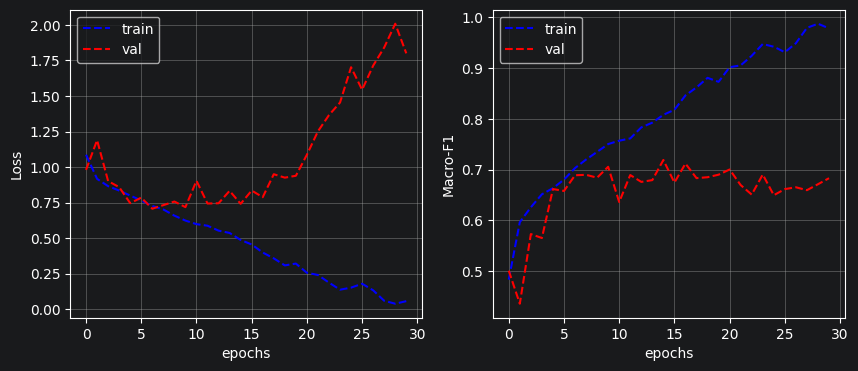

In [21]:
# Instantiate, Train, Plot
model_cnn = VGGNet(output_classes=4, dropout=0.0)
history = train_model(model_cnn, train_loader, val_loader, epochs=30, lr=1e-3, class_weights=cw)
plot_learning_curve(history['loss'], history['val_loss'], history['f1'], history['val_f1'], save_path=f'{FIG_DIR}/fig07_baseline_cnn_curve.png')

**Observations**
- Baseline CNN reaches ~0.73 validation macro f1, but overfits, as training f1 approaches 1.0 while validation plateaus
- Divergent curves show that the model memorises training patients rather than learning the general patterns
- validation plateaus at ~epoch 6
- Lack of regularisation leads to the model memorising the dataset
- Validation F1 is already above our 0.6 target
- Regularisation and Data Augmentation can be explored to potentially raise results

## 6. Hyperparameter Tuning

### 6.1. SVM Hyperparameter Tuning

C 1000.0  train f1 1.000  val f1 = 0.639
C 0100.0  train f1 1.000  val f1 = 0.639
C 0010.0  train f1 0.999  val f1 = 0.642
C 0001.0  train f1 0.912  val f1 = 0.674
C 0000.1  train f1 0.692  val f1 = 0.584


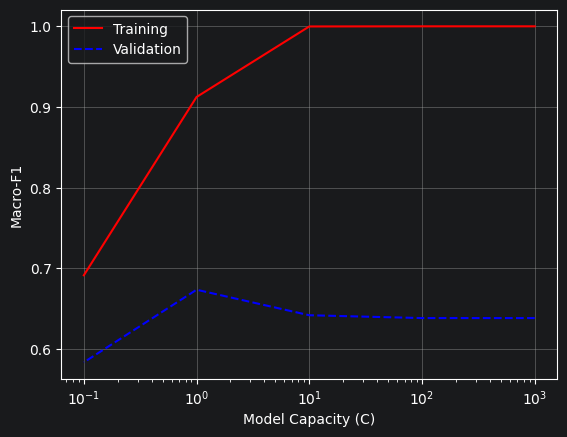

In [22]:
# Sweep C values spaced evenly on a log scale to scan orders of magnitude
lambda_params = np.logspace(-3, 1, num=5)
train_performace = []
valid_performace = []
for lam in lambda_params:
    clf = SVC(kernel='rbf', C=1.0/lam, class_weight='balanced', random_state=SEED).fit(train_X, train_y.ravel())
    tr, va = get_f1_scores(clf, train_X, train_y, val_X, val_y)
    print(f"C {(1.0/lam):06.1f}  train f1 {tr:.3f}  val f1 = {va:.3f}")
    train_performace.append(tr)
    valid_performace.append(va)

# plot results
plt.plot(1/lambda_params, train_performace, 'r-')
plt.plot(1/lambda_params, valid_performace, 'b--')
plt.xscale("log")
plt.xlabel('Model Capacity (C)')
plt.ylabel('Macro-F1')
plt.legend(['Training','Validation'])
plt.grid()
plt.savefig(f'{FIG_DIR}/fig05_svm_c_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations**
- Low C results in a modest training and validation score (), showing underfitting
- As C approaches 10, training F1 approaches 1, while val F1 stays stable
- C = 0.01 generalises best (~0.67 val f1), but still falls behind the basic CNN
- Tuning C across multiple orders of magnitude cannot raise the validation past ~0.64. This seems to be the ceiling for this model
- Sweep shows regularisation tradeoff. Large C memorises and overfits, small C underfits


### 6.2. CNN Learning Rate Tuning

epoch 01  loss 1.430/1.376  F1 0.238/0.153  (smoothed 0.153)
epoch 02  loss 1.297/1.240  F1 0.343/0.307  (smoothed 0.230)
epoch 03  loss 1.180/1.139  F1 0.399/0.411  (smoothed 0.290)
epoch 04  loss 1.027/0.964  F1 0.531/0.558  (smoothed 0.425)
epoch 05  loss 0.897/0.837  F1 0.614/0.577  (smoothed 0.515)
epoch 06  loss 0.877/0.943  F1 0.627/0.524  (smoothed 0.553)
epoch 07  loss 0.855/0.945  F1 0.633/0.501  (smoothed 0.534)
epoch 08  loss 0.835/0.828  F1 0.653/0.589  (smoothed 0.538)
epoch 09  loss 0.794/0.873  F1 0.673/0.581  (smoothed 0.557)
epoch 10  loss 0.812/0.880  F1 0.661/0.592  (smoothed 0.587)
epoch 11  loss 0.795/0.797  F1 0.670/0.604  (smoothed 0.592)
epoch 12  loss 0.779/0.856  F1 0.677/0.612  (smoothed 0.603)
epoch 13  loss 0.760/0.911  F1 0.691/0.580  (smoothed 0.598)
epoch 14  loss 0.743/0.908  F1 0.703/0.574  (smoothed 0.588)
epoch 15  loss 0.738/1.035  F1 0.703/0.530  (smoothed 0.561)
epoch 16  loss 0.760/0.895  F1 0.689/0.562  (smoothed 0.555)
epoch 17  loss 0.709/0.9

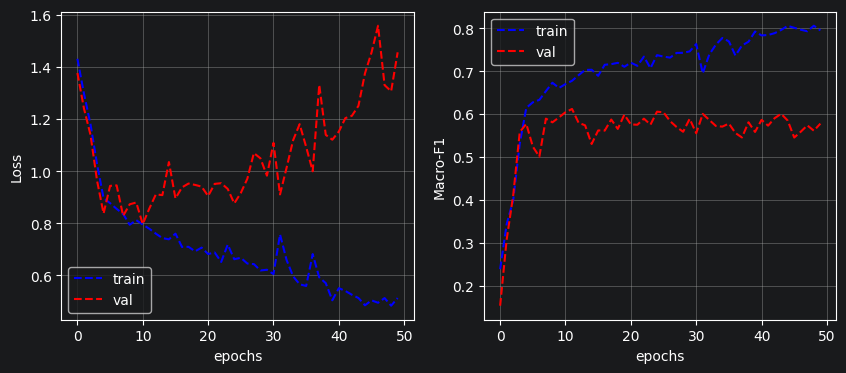

epoch 01  loss 1.136/0.931  F1 0.460/0.539  (smoothed 0.539)
epoch 02  loss 0.897/0.867  F1 0.603/0.585  (smoothed 0.562)
epoch 03  loss 0.838/0.811  F1 0.642/0.604  (smoothed 0.576)
epoch 04  loss 0.795/0.768  F1 0.667/0.631  (smoothed 0.607)
epoch 05  loss 0.777/0.772  F1 0.675/0.649  (smoothed 0.628)
epoch 06  loss 0.767/0.801  F1 0.687/0.627  (smoothed 0.636)
epoch 07  loss 0.730/0.700  F1 0.705/0.697  (smoothed 0.658)
epoch 08  loss 0.691/0.772  F1 0.726/0.664  (smoothed 0.663)
epoch 09  loss 0.650/0.723  F1 0.743/0.702  (smoothed 0.688)
epoch 10  loss 0.612/0.810  F1 0.759/0.635  (smoothed 0.667)
epoch 11  loss 0.575/0.764  F1 0.773/0.665  (smoothed 0.667)
epoch 12  loss 0.554/0.823  F1 0.782/0.639  (smoothed 0.647)
epoch 13  loss 0.523/0.683  F1 0.794/0.721  (smoothed 0.675)
epoch 14  loss 0.474/0.729  F1 0.813/0.701  (smoothed 0.687)
epoch 15  loss 0.440/0.884  F1 0.832/0.645  (smoothed 0.689)
epoch 16  loss 0.468/0.758  F1 0.817/0.697  (smoothed 0.681)
epoch 17  loss 0.442/0.8

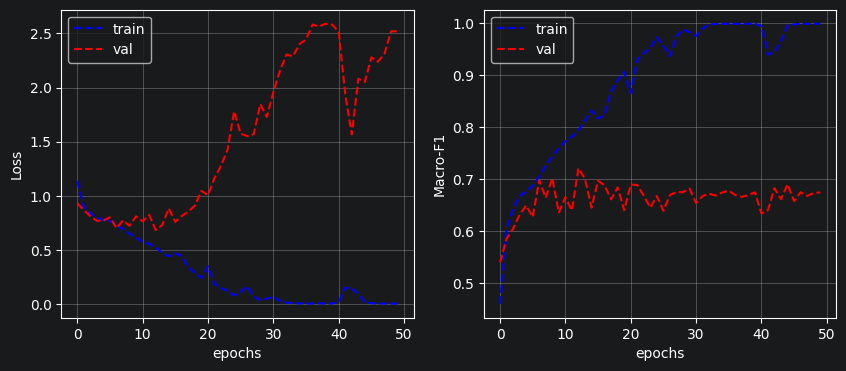

epoch 01  loss 1.337/1.105  F1 0.296/0.421  (smoothed 0.421)
epoch 02  loss 1.017/0.940  F1 0.544/0.495  (smoothed 0.458)
epoch 03  loss 0.913/0.823  F1 0.586/0.567  (smoothed 0.494)
epoch 04  loss 0.893/0.831  F1 0.598/0.600  (smoothed 0.554)
epoch 05  loss 0.875/0.828  F1 0.618/0.529  (smoothed 0.565)
epoch 06  loss 0.861/0.795  F1 0.624/0.631  (smoothed 0.587)
epoch 07  loss 0.857/0.789  F1 0.628/0.624  (smoothed 0.595)
epoch 08  loss 0.854/0.848  F1 0.633/0.541  (smoothed 0.599)
epoch 09  loss 0.833/0.793  F1 0.645/0.615  (smoothed 0.593)
epoch 10  loss 0.823/0.838  F1 0.647/0.588  (smoothed 0.581)
epoch 11  loss 0.822/0.810  F1 0.652/0.591  (smoothed 0.598)
epoch 12  loss 0.812/0.801  F1 0.656/0.618  (smoothed 0.599)
epoch 13  loss 0.803/0.824  F1 0.660/0.597  (smoothed 0.602)
epoch 14  loss 0.801/0.820  F1 0.662/0.589  (smoothed 0.601)
epoch 15  loss 0.789/0.780  F1 0.668/0.614  (smoothed 0.600)
epoch 16  loss 0.784/0.777  F1 0.673/0.630  (smoothed 0.611)
epoch 17  loss 0.781/0.7

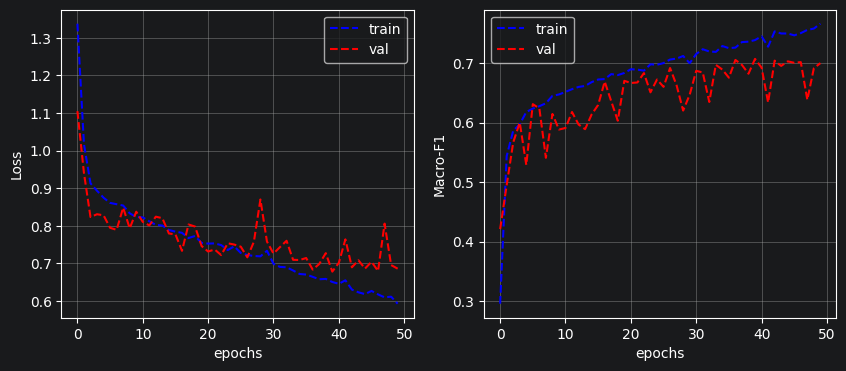

In [23]:
# Sweep learning rates (0.01, 0.001, 0.0001) WITHOUT BatchNorm
for lr in [1e-2, 1e-3, 1e-4]:
    m = VGGNet(output_classes=4, dropout=0.0, use_bn=False)
    h = train_model(m, train_loader, val_loader, epochs=50, lr=lr, class_weights=cw)
    print("lr", lr, "best val F1", max(h['val_f1']))
    plot_learning_curve(h['loss'], h['val_loss'], h['f1'], h['val_f1'], save_path=f'{FIG_DIR}/fig06_cnn_lr_sweep_{lr}.png')


**Observations**
- Checked across 3 learning rates: 0.01, 0.001, 0.0001
- lr 0.01: Too high, steps are too big. Both curves are unstable. Training bounces heavily, and val is a noisy climb
- lr 0.001: smooth curves and a strong validation peak. (In the recorded run the lowest lr, 1e-4, edged it on smoothed val-F1; re-confirm against the regenerated curves after re-running.)
- lr 0.0001: Too low. Moves are too gentle, and in 50 epochs, training F1 isn't able to reach 1.0. Validation loss is the most stable, but this is likely because it is too slow to overfit yet

**Adding in batch normalisation**
- Overfitting is flipped - 0.01 overfits first, 0.0001 overfits last
- Curves are much more disjointed
- Similar ceiling, but slight potential performance gain (more stably higher values than without batchnorm)

epoch 01  loss 1.276/0.917  F1 0.489/0.541  (smoothed 0.541)
epoch 02  loss 0.873/0.900  F1 0.614/0.647  (smoothed 0.594)
epoch 03  loss 0.850/0.826  F1 0.626/0.547  (smoothed 0.579)
epoch 04  loss 0.816/0.998  F1 0.646/0.582  (smoothed 0.592)
epoch 05  loss 0.784/0.783  F1 0.673/0.654  (smoothed 0.594)
epoch 06  loss 0.748/0.730  F1 0.687/0.698  (smoothed 0.645)
epoch 07  loss 0.702/0.914  F1 0.721/0.597  (smoothed 0.650)
epoch 08  loss 0.673/0.842  F1 0.732/0.665  (smoothed 0.654)
epoch 09  loss 0.639/0.885  F1 0.745/0.616  (smoothed 0.626)
epoch 10  loss 0.610/2.160  F1 0.758/0.510  (smoothed 0.597)
epoch 11  loss 0.618/0.975  F1 0.763/0.606  (smoothed 0.577)
epoch 12  loss 0.547/0.683  F1 0.788/0.702  (smoothed 0.606)
epoch 13  loss 0.543/1.362  F1 0.787/0.511  (smoothed 0.606)
epoch 14  loss 0.556/0.836  F1 0.776/0.693  (smoothed 0.635)
epoch 15  loss 0.497/0.773  F1 0.802/0.704  (smoothed 0.636)
epoch 16  loss 0.430/0.748  F1 0.830/0.730  (smoothed 0.709)
epoch 17  loss 0.423/0.8

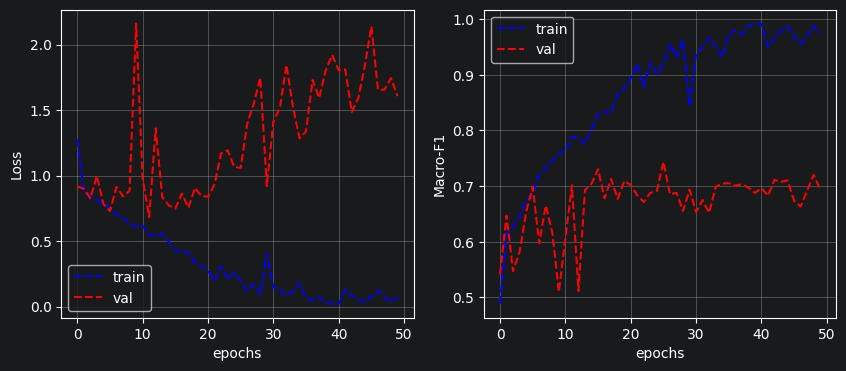

epoch 01  loss 0.909/0.981  F1 0.607/0.524  (smoothed 0.524)
epoch 02  loss 0.759/0.857  F1 0.687/0.616  (smoothed 0.570)
epoch 03  loss 0.677/0.666  F1 0.723/0.663  (smoothed 0.601)
epoch 04  loss 0.619/0.587  F1 0.756/0.732  (smoothed 0.670)
epoch 05  loss 0.587/0.662  F1 0.762/0.708  (smoothed 0.701)
epoch 06  loss 0.532/0.629  F1 0.790/0.732  (smoothed 0.724)
epoch 07  loss 0.463/0.811  F1 0.820/0.627  (smoothed 0.689)
epoch 08  loss 0.449/0.762  F1 0.826/0.687  (smoothed 0.682)
epoch 09  loss 0.420/0.753  F1 0.832/0.698  (smoothed 0.670)
epoch 10  loss 0.328/1.179  F1 0.874/0.598  (smoothed 0.661)
epoch 11  loss 0.309/0.767  F1 0.880/0.703  (smoothed 0.666)
epoch 12  loss 0.230/0.874  F1 0.913/0.714  (smoothed 0.672)
epoch 13  loss 0.163/0.946  F1 0.937/0.697  (smoothed 0.705)
epoch 14  loss 0.133/0.893  F1 0.947/0.717  (smoothed 0.709)
epoch 15  loss 0.094/1.059  F1 0.964/0.669  (smoothed 0.694)
epoch 16  loss 0.178/0.888  F1 0.927/0.708  (smoothed 0.698)
epoch 17  loss 0.072/1.0

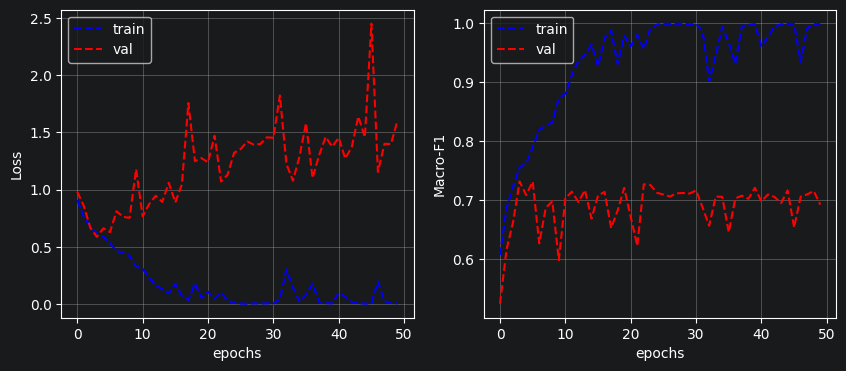

epoch 01  loss 1.021/0.857  F1 0.550/0.582  (smoothed 0.582)
epoch 02  loss 0.774/0.763  F1 0.689/0.658  (smoothed 0.620)
epoch 03  loss 0.673/0.737  F1 0.736/0.667  (smoothed 0.636)
epoch 04  loss 0.605/0.734  F1 0.766/0.661  (smoothed 0.662)
epoch 05  loss 0.533/0.645  F1 0.801/0.709  (smoothed 0.679)
epoch 06  loss 0.468/0.722  F1 0.828/0.683  (smoothed 0.684)
epoch 07  loss 0.398/0.734  F1 0.863/0.686  (smoothed 0.692)
epoch 08  loss 0.332/0.656  F1 0.891/0.718  (smoothed 0.696)
epoch 09  loss 0.281/0.786  F1 0.914/0.657  (smoothed 0.687)
epoch 10  loss 0.218/0.707  F1 0.941/0.704  (smoothed 0.693)
epoch 11  loss 0.179/0.838  F1 0.954/0.673  (smoothed 0.678)
epoch 12  loss 0.142/0.823  F1 0.966/0.681  (smoothed 0.686)
epoch 13  loss 0.121/1.080  F1 0.973/0.627  (smoothed 0.660)
epoch 14  loss 0.091/0.823  F1 0.982/0.699  (smoothed 0.669)
epoch 15  loss 0.086/0.847  F1 0.983/0.694  (smoothed 0.673)
epoch 16  loss 0.075/0.915  F1 0.984/0.681  (smoothed 0.691)
epoch 17  loss 0.052/0.8

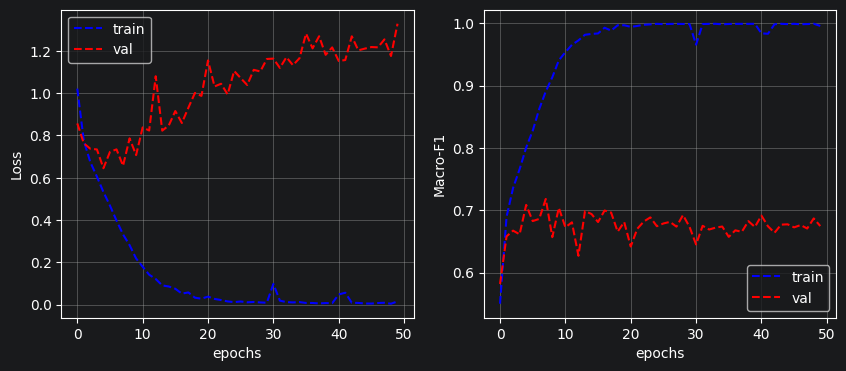

In [24]:
# Same sweep WITH BatchNorm (use_bn=True)
for lr in [1e-2, 1e-3, 1e-4]:
    m = VGGNet(output_classes=4, dropout=0.0, use_bn=True)
    h = train_model(m, train_loader, val_loader, epochs=50, lr=lr, class_weights=cw)
    print("lr", lr, "best val F1", max(h['val_f1']))
    plot_learning_curve(h['loss'], h['val_loss'], h['f1'], h['val_f1'], save_path=f'{FIG_DIR}/fig08_batchnorm_on_lr_{lr}.png')


**Notes**
- Adding BatchNorm changed the results rather significantly
- overfitting between learning rates flipped - higher learning rates resulted in faster overfitting

### 6.3. CNN Data Augmentation

epoch 01  loss 0.995/0.806  F1 0.551/0.650  (smoothed 0.650)
epoch 02  loss 0.870/0.736  F1 0.630/0.670  (smoothed 0.660)
epoch 03  loss 0.836/0.853  F1 0.642/0.554  (smoothed 0.625)
epoch 04  loss 0.802/0.768  F1 0.670/0.666  (smoothed 0.630)
epoch 05  loss 0.782/0.728  F1 0.675/0.671  (smoothed 0.630)
epoch 06  loss 0.731/0.810  F1 0.703/0.627  (smoothed 0.655)
epoch 07  loss 0.712/0.695  F1 0.715/0.703  (smoothed 0.667)
epoch 08  loss 0.701/0.569  F1 0.726/0.753  (smoothed 0.694)
epoch 09  loss 0.683/0.642  F1 0.735/0.727  (smoothed 0.728)
epoch 10  loss 0.655/0.676  F1 0.743/0.696  (smoothed 0.725)
epoch 11  loss 0.654/0.702  F1 0.738/0.691  (smoothed 0.705)
epoch 12  loss 0.637/0.710  F1 0.753/0.690  (smoothed 0.692)
epoch 13  loss 0.618/0.748  F1 0.761/0.718  (smoothed 0.700)
epoch 14  loss 0.609/0.664  F1 0.767/0.710  (smoothed 0.706)
epoch 15  loss 0.606/0.604  F1 0.765/0.746  (smoothed 0.725)
epoch 16  loss 0.586/0.644  F1 0.769/0.730  (smoothed 0.729)
epoch 17  loss 0.567/0.6

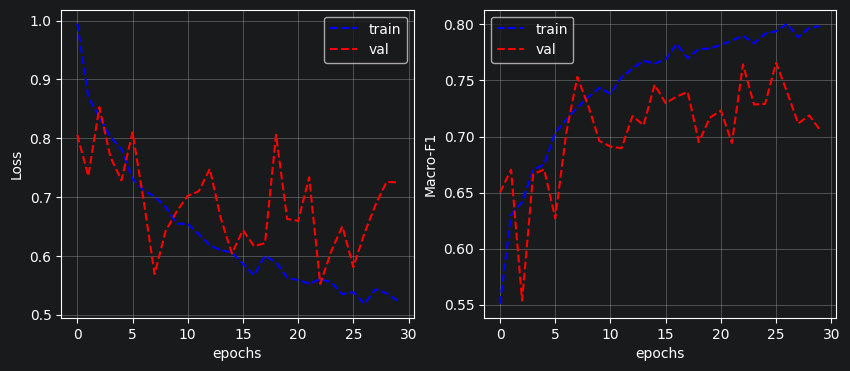

In [26]:
#  BatchNorm + augmentation
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    # transforms.ColorJitter(brightness=(0.7, 1.3)),  # stain darkness is real signal; jitter hurt
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5]),
])

# Only augment training set
train_loader_aug = DataLoader(
    CellDataset(train_data_t, IMG_DIR, LABEL_COL, aug_transform),
    batch_size=batch_size,
    shuffle=True
)

torch.manual_seed(SEED)
model_aug = VGGNet(output_classes=4, dropout=0.2, use_bn=True)
history_aug = train_model(
    model_aug, train_loader_aug, val_loader,
    epochs=30, lr=1e-3, weight_decay=5e-4, class_weights=cw,
    save_path='final_celltype_cnn.pth'
)
plot_learning_curve(
    history_aug['loss'],
    history_aug['val_loss'],
    history_aug['f1'],
    history_aug['val_f1'],
    save_path=f'{FIG_DIR}/fig10_aug_cnn_curve_celltype.png'
)


**Notes**
- Added random flips, rotations, translation, brightness changes to the Training images
- Added dropout 0.2 and weight decay 5e-4. With BatchNorm enabled the final model uses lr 1e-3 (BN lifted every lr in the sweep and supports the higher rate).
- Compared to the baseline with the same lr:
- Training F1 no longer hits 1.0, and validation loss no longer explodes to over 3.0 - Much less severe overfitting
- Validation loss stabilises at around 0.8 - 0.9, and validation F1 plateaus at ~0.66, peaking at over 0.67
- Much more stable, which should help with unseen data
- Best validation F1 checkpoint is saved as the final model
- Brightness jitter removed. Stain darkness is real class signal and jitter was messing with it causing poor results


### 6.4. Patient-grouped k-fold cross validation (by cell type)

In [27]:
# Patient-grouped stratified k-fold

# Group train and val pools. Keep test separate
development_data = pd.concat([train_data_t, val_data_t]).reset_index(drop=True)

NUMBER_OF_FOLDS = 5
EPOCHS_PER_FOLD = 20
# for tweaking 'others' class weighting
OTHERS_WEIGHT_BOOST = 1.0

sgkfold = StratifiedGroupKFold(
    n_splits=NUMBER_OF_FOLDS, shuffle=True, random_state=SEED)

fold_macro_f1_scores = []
fold_histories = []

for fold_number, (train_index, validation_index) in enumerate(
        sgkfold.split(development_data, development_data['cellType'], development_data['patientID'])):

    train_fold_data = development_data.iloc[train_index]
    validation_fold_data = development_data.iloc[validation_index]

    train_fold_loader = DataLoader(
        CellDataset(train_fold_data, IMG_DIR, 'cellType', aug_transform),
        batch_size=batch_size, shuffle=True)
    validation_fold_loader = DataLoader(
        CellDataset(validation_fold_data, IMG_DIR, 'cellType', val_transform),
        batch_size=batch_size, shuffle=False)

    # class weights recomputed on this fold's training labels
    class_weights_fold = compute_class_weight(
        'balanced', classes=np.array([0, 1, 2, 3]),
        y=train_fold_data['cellType'].to_numpy())
    class_weights_fold = torch.tensor(class_weights_fold, dtype=torch.float32)
    class_weights_fold[3] *= OTHERS_WEIGHT_BOOST   # index 3 = 'others'

    # seed model on each fold
    torch.manual_seed(SEED)
    fold_model = VGGNet(output_classes=4, dropout=0.2, use_bn=True)
    fold_history = train_model(
        fold_model, train_fold_loader, validation_fold_loader,
        epochs=EPOCHS_PER_FOLD, lr=1e-3, weight_decay=1e-4,
        class_weights=class_weights_fold)   # no patience -> equal-length histories for the plot

    # macro-F1 of the best checkpoint model on this fold
    fold_model.eval()
    fold_predictions, fold_true_labels = [], []
    with torch.no_grad():
        for images, labels in validation_fold_loader:
            fold_predictions  += fold_model(images.to(device)).argmax(1).cpu().tolist()
            fold_true_labels  += labels.tolist()
    fold_score = f1_score(fold_true_labels, fold_predictions, average='macro')
    print(f"Fold {fold_number + 1} macro-F1: {fold_score:.3f}")
    fold_macro_f1_scores.append(fold_score)
    fold_histories.append(fold_history)

print(f"\nCNN grouped-CV macro-F1: {np.mean(fold_macro_f1_scores):.3f} +- {np.std(fold_macro_f1_scores):.3f}")

epoch 01  loss 0.932/0.867  F1 0.580/0.561  (smoothed 0.561)
epoch 02  loss 0.833/1.032  F1 0.642/0.505  (smoothed 0.533)
epoch 03  loss 0.793/0.817  F1 0.665/0.646  (smoothed 0.571)
epoch 04  loss 0.748/0.866  F1 0.687/0.640  (smoothed 0.597)
epoch 05  loss 0.716/0.838  F1 0.705/0.636  (smoothed 0.641)
epoch 06  loss 0.688/0.744  F1 0.721/0.662  (smoothed 0.646)
epoch 07  loss 0.692/0.649  F1 0.704/0.692  (smoothed 0.663)
epoch 08  loss 0.664/0.681  F1 0.728/0.703  (smoothed 0.686)
epoch 09  loss 0.654/0.632  F1 0.728/0.746  (smoothed 0.714)
epoch 10  loss 0.644/0.659  F1 0.737/0.714  (smoothed 0.721)
epoch 11  loss 0.616/0.703  F1 0.756/0.683  (smoothed 0.714)
epoch 12  loss 0.616/0.654  F1 0.747/0.739  (smoothed 0.712)
epoch 13  loss 0.601/0.666  F1 0.754/0.724  (smoothed 0.715)
epoch 14  loss 0.594/0.592  F1 0.767/0.760  (smoothed 0.741)
epoch 15  loss 0.597/0.658  F1 0.760/0.737  (smoothed 0.740)
epoch 16  loss 0.586/0.611  F1 0.759/0.739  (smoothed 0.745)
epoch 17  loss 0.577/0.6

- others tweak not used. It feels like cheating to raise scores by making one class arbitrarily contribute less

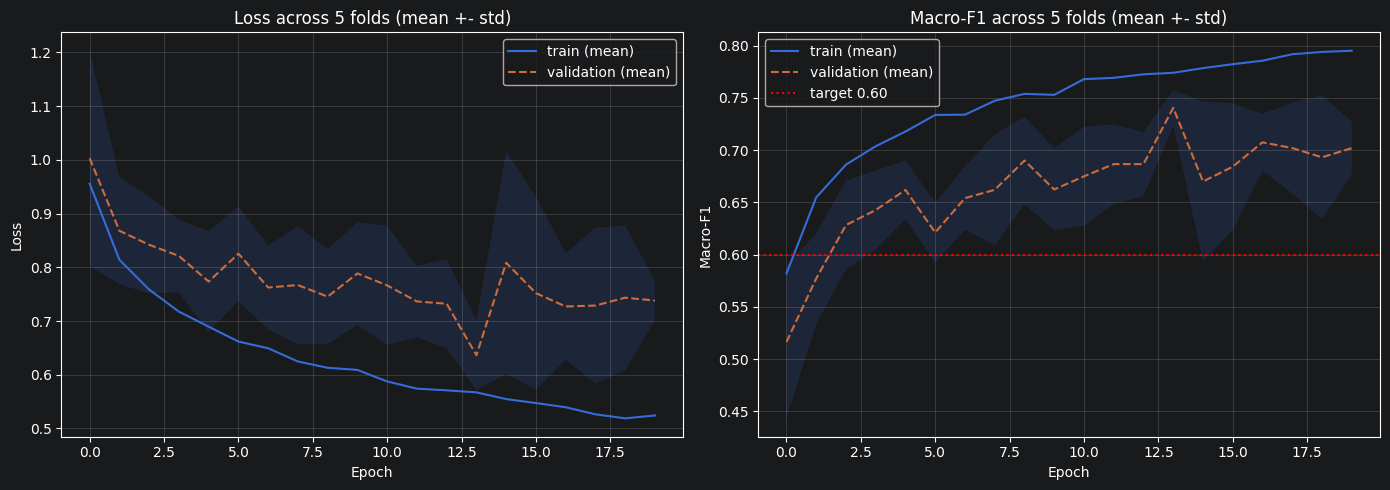

In [28]:
# issues on early-finish. Folds won't stack perfectly
train_f1_across_folds   = np.array([h['f1']       for h in fold_histories])
val_f1_across_folds     = np.array([h['val_f1']   for h in fold_histories])
train_loss_across_folds = np.array([h['loss']     for h in fold_histories])
val_loss_across_folds   = np.array([h['val_loss'] for h in fold_histories])
epoch_axis = np.arange(train_f1_across_folds.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_axis, train_loss_across_folds.mean(axis=0), '-',  label='train (mean)')
axes[0].plot(epoch_axis, val_loss_across_folds.mean(axis=0),  '--', label='validation (mean)')
axes[0].fill_between(epoch_axis,
                     val_loss_across_folds.mean(axis=0) - val_loss_across_folds.std(axis=0),
                     val_loss_across_folds.mean(axis=0) + val_loss_across_folds.std(axis=0), alpha=0.15)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss across 5 folds (mean +- std)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epoch_axis, train_f1_across_folds.mean(axis=0), '-',  label='train (mean)')
axes[1].plot(epoch_axis, val_f1_across_folds.mean(axis=0),  '--', label='validation (mean)')
axes[1].fill_between(epoch_axis,
                     val_f1_across_folds.mean(axis=0) - val_f1_across_folds.std(axis=0),
                     val_f1_across_folds.mean(axis=0) + val_f1_across_folds.std(axis=0), alpha=0.15)
axes[1].axhline(0.60, color='red', linestyle=':', label='target 0.60')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro-F1')
axes[1].set_title('Macro-F1 across 5 folds (mean +- std)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig11_crossval_meanstd.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.5. Final cellType test evaluation

              precision    recall  f1-score   support

  fibroblast      0.510     0.631     0.564       390
inflammatory      0.758     0.817     0.786       475
  epithelial      0.880     0.933     0.905       861
      others      0.386     0.138     0.204       282

    accuracy                          0.735      2008
   macro avg      0.633     0.630     0.615      2008
weighted avg      0.710     0.735     0.712      2008

cell-type TEST macro-F1: 0.6148


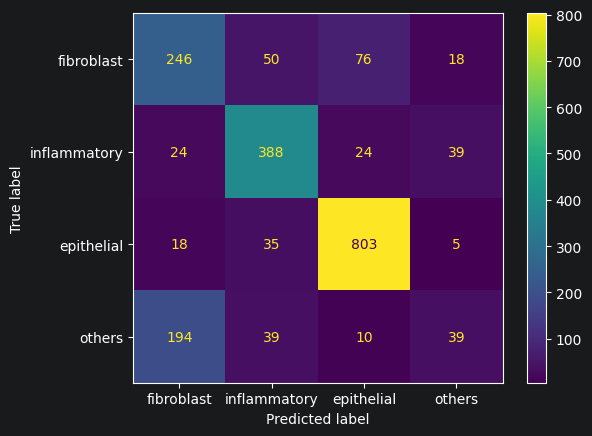

In [29]:
# Use the best checkpoint to evaluate test set
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

final_celltype_model = VGGNet(output_classes=4, dropout=0.2, use_bn=True)
final_celltype_model.load_state_dict(torch.load('final_celltype_cnn.pth'))
final_celltype_model = final_celltype_model.to(device)
final_celltype_model.eval()

test_loader_celltype = DataLoader(
    CellDataset(test_data_t, IMG_DIR, 'cellType', val_transform),
    batch_size=batch_size, shuffle=False)

test_predictions, test_true_labels = [], []
with torch.no_grad():
    for images, labels in test_loader_celltype:
        test_predictions += final_celltype_model(images.to(device)).argmax(1).cpu().tolist()
        test_true_labels += labels.tolist()

class_names = ['fibroblast', 'inflammatory', 'epithelial', 'others']
print(classification_report(test_true_labels, test_predictions,
                            target_names=class_names, digits=3))
print("cell-type TEST macro-F1:",
      round(f1_score(test_true_labels, test_predictions, average='macro'), 4))
ConfusionMatrixDisplay.from_predictions(test_true_labels, test_predictions,
                                        display_labels=class_names)
plt.savefig(f'{FIG_DIR}/fig13_celltype_test_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Cancer Detection

Note: The framework for the first task was created with reusability in mind. Most of the workflow is therefore very similar

### 7.1. Simple Models (LR, SVM, RF)

In [30]:
# Flattened and scaled cancer arrays
train_Xc = load_images(train_data_c).reshape(len(train_data_c), -1)
val_Xc   = load_images(val_data_c).reshape(len(val_data_c), -1)
test_Xc  = load_images(test_data_c).reshape(len(test_data_c), -1)

train_yc = train_data_c['isCancerous'].to_numpy()
val_yc   = val_data_c['isCancerous'].to_numpy()
test_yc  = test_data_c['isCancerous'].to_numpy()

scaler_c = StandardScaler().fit(train_Xc)
train_Xc, val_Xc, test_Xc = scaler_c.transform(train_Xc), scaler_c.transform(val_Xc), scaler_c.transform(test_Xc)

# Logistic Regression
clf_lr_c = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_lr_c.fit(train_Xc, train_yc.ravel())
print("LR  :", get_f1_scores(clf_lr_c, train_Xc, train_yc, val_Xc, val_yc))

# SVM - RBF kernel
clf_svm_c = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=SEED)
clf_svm_c.fit(train_Xc, train_yc.ravel())
print("SVM :", get_f1_scores(clf_svm_c, train_Xc, train_yc, val_Xc, val_yc))

# Random Forest
clf_rf_c = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
clf_rf_c.fit(train_Xc, train_yc.ravel())
print("RF  :", get_f1_scores(clf_rf_c, train_Xc, train_yc, val_Xc, val_yc))

LR  : (0.9013092479384883, 0.8015666414237032)
SVM : (0.9543900193710864, 0.8601473048640296)
RF  : (0.9999123376002379, 0.8470908992770785)


**Observations**
- Genuinely very good results, likely due to the binary nature of the classification allowing for linear models to perform

### 7.2 isCancer CNN

In [31]:
# create new isCancerous dataloaders
train_loader_c = DataLoader(
    CellDataset(train_data_c, IMG_DIR, 'isCancerous', val_transform),
    batch_size=batch_size,
    shuffle=True
)

# augmented transformations can be reused
train_loader_augc = DataLoader(
    CellDataset(train_data_c, IMG_DIR, 'isCancerous', aug_transform),
    batch_size=batch_size,
    shuffle=True
)
val_loader_c = DataLoader(CellDataset(
    val_data_c, IMG_DIR, 'isCancerous', val_transform),
    batch_size=batch_size,
    shuffle=False
)
test_loader_c = DataLoader(
    CellDataset(test_data_c, IMG_DIR, 'isCancerous', val_transform),
    batch_size=batch_size,
    shuffle=False
)

# isCancer class weights
cw_c = torch.tensor(compute_class_weight('balanced', classes=np.unique(train_yc), y=train_yc), dtype=torch.float32)

epoch 01  loss 0.448/0.403  F1 0.766/0.809  (smoothed 0.809)
epoch 02  loss 0.310/0.462  F1 0.864/0.790  (smoothed 0.800)
epoch 03  loss 0.282/0.317  F1 0.879/0.858  (smoothed 0.819)
epoch 04  loss 0.251/0.320  F1 0.893/0.856  (smoothed 0.835)
epoch 05  loss 0.240/0.316  F1 0.900/0.862  (smoothed 0.859)
epoch 06  loss 0.247/0.331  F1 0.897/0.858  (smoothed 0.859)
epoch 07  loss 0.222/0.305  F1 0.908/0.870  (smoothed 0.863)
epoch 08  loss 0.233/0.312  F1 0.902/0.867  (smoothed 0.865)
epoch 09  loss 0.218/0.297  F1 0.910/0.870  (smoothed 0.869)
epoch 10  loss 0.216/0.340  F1 0.909/0.849  (smoothed 0.862)
epoch 11  loss 0.207/0.404  F1 0.912/0.831  (smoothed 0.850)
epoch 12  loss 0.206/0.269  F1 0.914/0.879  (smoothed 0.853)
epoch 13  loss 0.195/0.322  F1 0.918/0.867  (smoothed 0.859)
epoch 14  loss 0.193/0.327  F1 0.920/0.854  (smoothed 0.867)
epoch 15  loss 0.193/0.293  F1 0.919/0.873  (smoothed 0.864)
epoch 16  loss 0.190/0.350  F1 0.922/0.853  (smoothed 0.860)
epoch 17  loss 0.188/0.2

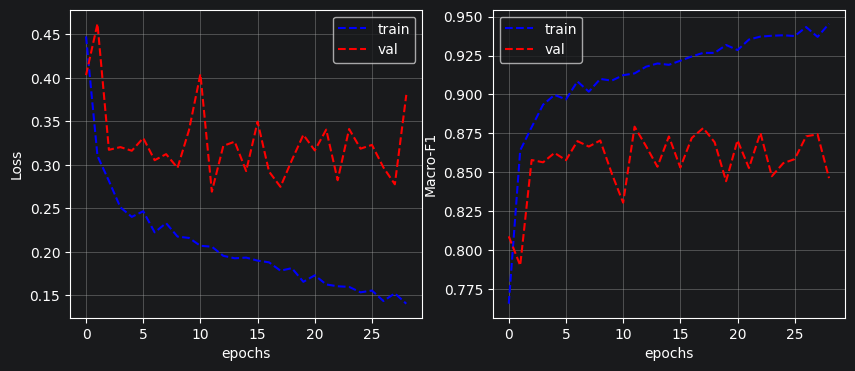

In [32]:
# Baseline cancer CNN: no BatchNorm, no augmentation
torch.manual_seed(SEED)
model_cnn_c = VGGNet(output_classes=2, dropout=0.3, use_bn=False)
history_c = train_model(model_cnn_c, train_loader_c, val_loader_c,
                        epochs=30, lr=5e-4, weight_decay=1e-3,
                        class_weights=cw_c, patience=10,
                        save_path='cancer_cnn_baseline.pth')
plot_learning_curve(history_c['loss'], history_c['val_loss'], history_c['f1'], history_c['val_f1'], save_path=f'{FIG_DIR}/fig09_cancer_cnn_curve.png')


epoch 01  loss 0.281/0.338  F1 0.874/0.860  (smoothed 0.860)
epoch 02  loss 0.226/0.297  F1 0.902/0.861  (smoothed 0.860)
epoch 03  loss 0.205/0.313  F1 0.915/0.849  (smoothed 0.857)
epoch 04  loss 0.186/0.265  F1 0.922/0.881  (smoothed 0.864)
epoch 05  loss 0.169/0.451  F1 0.930/0.814  (smoothed 0.848)
epoch 06  loss 0.158/0.329  F1 0.936/0.858  (smoothed 0.851)
epoch 07  loss 0.135/0.409  F1 0.945/0.863  (smoothed 0.845)
epoch 08  loss 0.126/0.344  F1 0.949/0.855  (smoothed 0.859)
epoch 09  loss 0.104/0.323  F1 0.958/0.869  (smoothed 0.862)
epoch 10  loss 0.093/0.289  F1 0.963/0.864  (smoothed 0.863)
epoch 11  loss 0.072/0.492  F1 0.971/0.836  (smoothed 0.856)
epoch 12  loss 0.057/0.400  F1 0.978/0.872  (smoothed 0.857)
epoch 13  loss 0.045/0.724  F1 0.982/0.809  (smoothed 0.839)
epoch 14  loss 0.046/0.548  F1 0.981/0.856  (smoothed 0.846)
early stop at epoch 14
best smoothed val F1: 0.8637


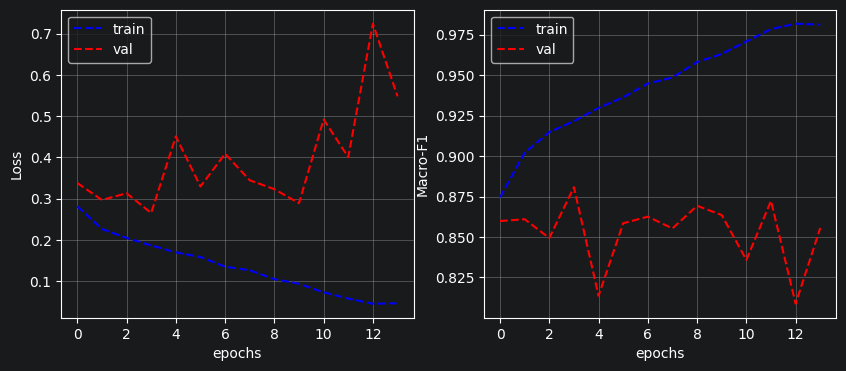

In [33]:
# Same config WITH BatchNorm
torch.manual_seed(SEED)
model_cnn_c = VGGNet(output_classes=2, dropout=0.3, use_bn=True)
history_c = train_model(model_cnn_c, train_loader_c, val_loader_c,
                        epochs=30, lr=5e-4, weight_decay=1e-3,
                        class_weights=cw_c, patience=10,
                        save_path='cancer_cnn_bn.pth')
plot_learning_curve(history_c['loss'], history_c['val_loss'], history_c['f1'], history_c['val_f1'], save_path=f'{FIG_DIR}/fig09b_cancer_cnn_bn_variant.png')


**Notes**
- Switched to stronger regularisation to slow fast overfitting (dropout 0.2 --> 0.3, lr 0.001 --> 0.0005)

### 7.3. isCancer Augmented CNN

epoch 01  loss 0.544/0.465  F1 0.683/0.753  (smoothed 0.753)
epoch 02  loss 0.408/0.459  F1 0.810/0.766  (smoothed 0.759)
epoch 03  loss 0.373/0.344  F1 0.824/0.844  (smoothed 0.788)
epoch 04  loss 0.346/0.392  F1 0.841/0.819  (smoothed 0.809)
epoch 05  loss 0.322/0.334  F1 0.853/0.846  (smoothed 0.836)
epoch 06  loss 0.311/0.325  F1 0.860/0.853  (smoothed 0.839)
epoch 07  loss 0.298/0.349  F1 0.867/0.823  (smoothed 0.841)
epoch 08  loss 0.296/0.343  F1 0.869/0.835  (smoothed 0.837)
epoch 09  loss 0.295/0.361  F1 0.869/0.846  (smoothed 0.835)
epoch 10  loss 0.283/0.350  F1 0.878/0.828  (smoothed 0.836)
epoch 11  loss 0.279/0.324  F1 0.879/0.852  (smoothed 0.842)
epoch 12  loss 0.271/0.309  F1 0.882/0.859  (smoothed 0.846)
epoch 13  loss 0.279/0.312  F1 0.881/0.851  (smoothed 0.854)
epoch 14  loss 0.278/0.318  F1 0.879/0.851  (smoothed 0.854)
epoch 15  loss 0.269/0.315  F1 0.886/0.849  (smoothed 0.850)
epoch 16  loss 0.260/0.318  F1 0.890/0.849  (smoothed 0.850)
epoch 17  loss 0.268/0.4

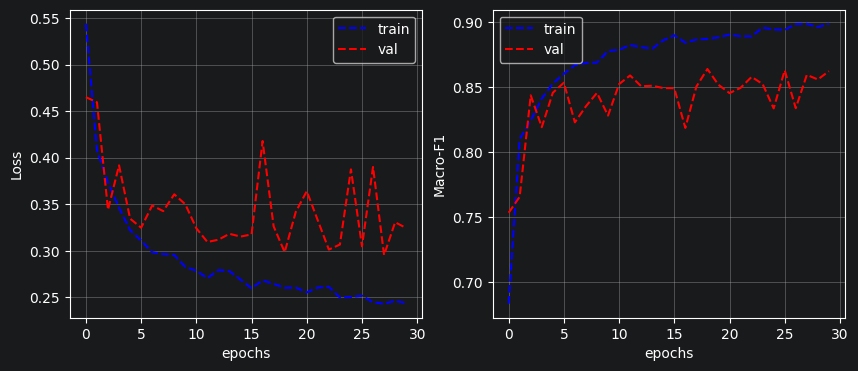

In [34]:
# Augmented cancer CNN WITHOUT BatchNorm
torch.manual_seed(SEED)
model_aug_c = VGGNet(output_classes=2, dropout=0.3, use_bn=False)
history_aug_c = train_model(model_aug_c, train_loader_augc, val_loader_c,
                            epochs=30, lr=5e-4, weight_decay=1e-3,
                            class_weights=cw_c, patience=10,
                            save_path='cancer_cnn_aug_nobn.pth')
plot_learning_curve(history_aug_c['loss'], history_aug_c['val_loss'], history_aug_c['f1'], history_aug_c['val_f1'], save_path=f'{FIG_DIR}/fig12_aug_cancer_cnn_curve.png')


epoch 01  loss 0.331/0.321  F1 0.847/0.863  (smoothed 0.863)
epoch 02  loss 0.271/0.301  F1 0.886/0.860  (smoothed 0.862)
epoch 03  loss 0.260/0.831  F1 0.892/0.684  (smoothed 0.803)
epoch 04  loss 0.248/0.321  F1 0.892/0.860  (smoothed 0.802)
epoch 05  loss 0.237/0.337  F1 0.901/0.851  (smoothed 0.798)
epoch 06  loss 0.235/0.290  F1 0.904/0.872  (smoothed 0.861)
epoch 07  loss 0.231/0.286  F1 0.903/0.863  (smoothed 0.862)
epoch 08  loss 0.224/0.312  F1 0.906/0.851  (smoothed 0.862)
epoch 09  loss 0.218/0.252  F1 0.909/0.880  (smoothed 0.864)
epoch 10  loss 0.212/0.239  F1 0.913/0.884  (smoothed 0.872)
epoch 11  loss 0.212/0.242  F1 0.910/0.888  (smoothed 0.884)
epoch 12  loss 0.221/0.285  F1 0.907/0.859  (smoothed 0.877)
epoch 13  loss 0.211/0.297  F1 0.912/0.867  (smoothed 0.871)
epoch 14  loss 0.208/0.283  F1 0.913/0.848  (smoothed 0.858)
epoch 15  loss 0.201/0.289  F1 0.916/0.858  (smoothed 0.858)
epoch 16  loss 0.198/0.260  F1 0.916/0.875  (smoothed 0.860)
epoch 17  loss 0.197/0.2

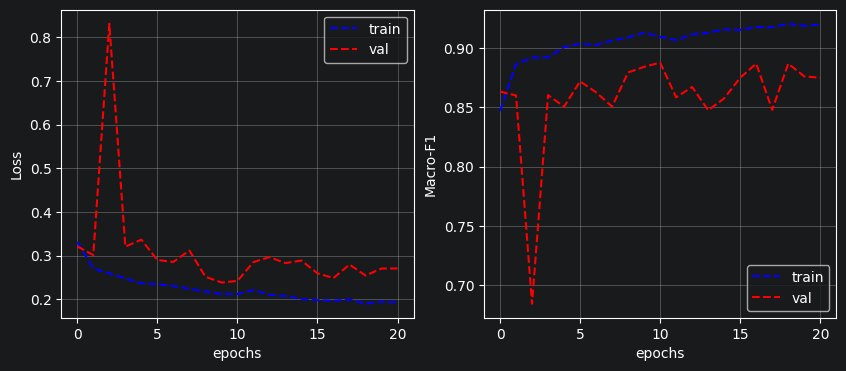

In [35]:
# BatchNorm + augmentation, lr 5e-4 (the only config that reached ~0.90 val)
torch.manual_seed(SEED)
model_aug_c = VGGNet(output_classes=2, dropout=0.3, use_bn=True)
history_aug_c = train_model(model_aug_c, train_loader_augc, val_loader_c,
                            epochs=30, lr=5e-4, weight_decay=1e-3,
                            class_weights=cw_c, patience=10,
                            save_path='final_cancer_cnn_aug.pth')
plot_learning_curve(history_aug_c['loss'], history_aug_c['val_loss'], history_aug_c['f1'], history_aug_c['val_f1'], save_path=f'{FIG_DIR}/fig12b_aug_cancer_cnn_bn_variant.png')


### 7.4. Final isCancer Test Evaluation

               precision    recall  f1-score   support

not cancerous      0.875     0.933     0.903      2583
    cancerous      0.854     0.747     0.797      1356

     accuracy                          0.869      3939
    macro avg      0.865     0.840     0.850      3939
 weighted avg      0.868     0.869     0.867      3939

cancer TEST macro-F1: 0.8502


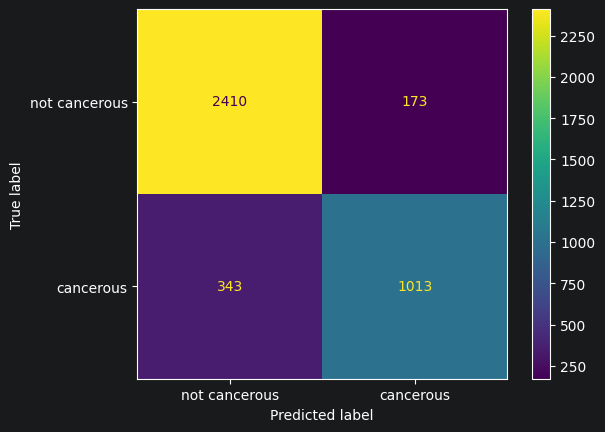

In [37]:
# Use the best checkpoint to evaluate test set. checkpoint selected on validation (best smoothed val F1)
final_cancer_model = VGGNet(output_classes=2, dropout=0.3, use_bn=True)
# final_cancer_model.load_state_dict(torch.load('final_cancer_cnn.pth'))
final_cancer_model.load_state_dict(torch.load('final_cancer_cnn_aug.pth'))
final_cancer_model = final_cancer_model.to(device)
final_cancer_model.eval()

test_loader_cancer = DataLoader(
    CellDataset(test_data_c, IMG_DIR, 'isCancerous', val_transform),
    batch_size=batch_size, shuffle=False)

test_predictions, test_true_labels = [], []
with torch.no_grad():
    for images, labels in test_loader_cancer:
        test_predictions += final_cancer_model(images.to(device)).argmax(1).cpu().tolist()
        test_true_labels += labels.tolist()

class_names = ['not cancerous', 'cancerous']
print(classification_report(test_true_labels, test_predictions,
                            target_names=class_names, digits=3))
print("cancer TEST macro-F1:",
      round(f1_score(test_true_labels, test_predictions, average='macro'), 4))
ConfusionMatrixDisplay.from_predictions(test_true_labels, test_predictions,
                                        display_labels=class_names)
plt.savefig(f'{FIG_DIR}/fig14_cancer_test_confusion.png', dpi=300, bbox_inches='tight')
plt.show()